<a href="https://colab.research.google.com/github/TheNehaShukla/toxicity-detection/blob/main/Fine_Tuning_DistillBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning DistillBERT for Toxicity Detection



### 1. Global Variables

In [ ]:
# imports
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import torch.nn as nn
from torch.nn import CrossEntropyLoss

In [ ]:
# Confirm GPU status
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

In [ ]:
model_name= "distilbert-base-uncased"
seed= 372
max_length= 256

#policies generated by ChatGPT
policies={
    "A": """You are an evaluator model whose job is to identify toxic or unsafe content generated in an LLM conversation. Classify as toxic if any of the following documented risks are present:
1. GAI System Toxic Content Generation. Definition: The risk that Generative Artificial Intelligence (GAI) systems may inadvertently produce or perpetuate harmful, explicit, or illegal content due to inadequately filtered training data, insufficient safeguards, or flawed ethical alignment.
2. Simulated Toxic Interaction. Definition: The risk that GAI systems proactively generate simulated interactions—such as unwarranted intimate contact, sexualized scenarios, or coercive dynamics, without user intent or explicit prompting, particularly in role-playing contexts.
3. Malicious Exploitation. Definition: The risk that adversarial actors may weaponize GAI systems to spread disinformation, engage in cyber abuse, or execute fraudulent schemes by leveraging AI-generated content.
4. Harmful Behavioral Influence. Definition: The risk that generative AI (GAI) systems fail to detect, mitigate, or redirect user-initiated toxic or harmful behaviors, such as self-harm, bullying, substance abuse, or violence—particularly when engaged by youth. This occurs when GAI responds to harmful intent (e.g., a user asking for methods to self-injure) by validating, enabling, or escalating the behavior (e.g., providing dangerous instructions) instead of deploying safeguards like blocking the request, offering mental health resources, or alerting guardians.

Additionally, classify the text as toxic if it contains harassment, hate speech, threats, abuse, demeaning language, or harmful unsafe content. Otherwise classify it as safe.
""",
    "B": """Classify the text as toxic if it contains harassment, hate speech, threats, abuse, demeaning language, or harmful unsafe content. Otherwise classify it as safe.""",
    "C": """Classify the text as toxic only if it contains direct encouragement of harm. Mild rudeness, profanity, or disagreement is safe. """
}

In [ ]:
print(policies)

### 2. Load and Split Data

In [ ]:
def load_toxicchat():
  dataset= load_dataset("lmsys/toxic-chat", "toxicchat0124")
  combined_dfs= []
  for split in dataset.keys():
    combined_dfs.append(dataset[split].to_pandas())
  df= pd.concat(combined_dfs, ignore_index=True)
  return df

def preprocess_and_split(df):
  text_column= "user_input"
  label_column= "toxicity"

  # Preprocessing: keep only relevant columns, drop-na, keep only human annotations
  df= df[[text_column,label_column, "human_annotation"]].dropna()
  df= df[df["human_annotation"]==True]

  # Rename columns; labels are integers such that 0 is safe, and 1 is toxic/unsafe
  df= df.rename(columns={text_column:"text", label_column: "label"})
  df["label"]= df["label"].astype(int)

  # Proper train/validation/test split
  train_df, other_df= train_test_split(df, test_size=0.2, stratify=df["label"], random_state=372)
  val_df, test_df= train_test_split(other_df, test_size=0.5, stratify=other_df["label"], random_state=372)

  print("Split sizes:")
  print("Train:", len(train_df))
  print("Validation:", len(val_df))
  print("Test:", len(test_df))
  print("\nLabel distribution:")
  print(train_df["label"].value_counts(normalize=True))

  return (train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True))



### Dataset Classes

In [ ]:
class ToxicPromptDataset( torch.utils.data.Dataset):
  def __init__(self, texts, labels, tokenizer, max_length= 256):
    self.texts= texts
    self.labels= labels
    self.tokenizer= tokenizer
    self.max_length= max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, index):
    text= str(self.texts[index])
    label= int(self.labels[index])
    encoded= self.tokenizer(text, truncation=True, padding= "max_length", max_length= self.max_length, return_tensors="pt")
    return {"input_ids": encoded["input_ids"].squeeze(0),
        "attention_mask": encoded["attention_mask"].squeeze(0),
        "labels":torch.tensor(label)}

class PolicyTextDataset(torch.utils.data.Dataset):
  def __init__(self, policies, texts, labels, tokenizer, max_length= 256):
    self.policies= policies
    self.texts= texts
    self.labels= labels
    self.tokenizer= tokenizer
    self.max_length= max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, index):
    policy= str(self.policies[index])
    text= str(self.texts[index])
    label= int(self.labels[index])
    encoded= self.tokenizer(policy, text, truncation=True, padding= "max_length", max_length= self.max_length, return_tensors="pt")
    return {"input_ids": encoded["input_ids"].squeeze(0),
        "attention_mask": encoded["attention_mask"].squeeze(0),
        "labels":torch.tensor(label)}


### Metrics Printout

In [ ]:
def compute_metrics(evaluate_predictions):
  logits, labels= evaluate_predictions
  predictions= np.argmax(logits, axis=1)
  precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="binary", zero_division=0)
  accuracy= accuracy_score(labels, predictions)
  return {"accuracy":accuracy, "precision":precision, "recall": recall, "f1": f1}

In [ ]:
import matplotlib.pyplot as plt

def training_history(trainer):
  rows=[]
  for log in trainer.sate.log_history:
    row={}
    if "epoch" in log:
      row["epoch"]=log["epoch"]
    if "loss" in log:
      row["train_loss"]=log["loss"]
    if "eval_loss" in log:
      row["val_loss"]=log["eval_loss"]
    if "eval_accuracy" in log:
      row["val_accuracy"]=log["eval_accuracy"]
    if "eval_precision" in log:
      row["val_precision"]=log["eval_precision"]
    if "eval_recall" in log:
      row["val_recall"]=log["eval_recall"]
    if "eval_f1" in log:
      row["val_f1"]=log["eval_f1"]
    if row:
      rows.append(row)
  return pd.DataFrame(rows)


### Weighted Trainer


In [ ]:
class WeightedTrainer(Trainer):
  def __init__(self, class_weights=None, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self.class_weights= class_weights
  def compute_loss(self, model, inputs, return_outputs=False,**kwargs):
    labels= inputs.pop("labels")
    outputs= model(**inputs)
    logits= outputs.logits
    loss_fct= CrossEntropyLoss(weight= self.class_weights.to(logits.device))
    loss= loss_fct(logits, labels)
    return (loss, outputs) if return_outputs else loss
def get_class_weights(train_df):
  num_safe=(train_df["label"]==0).sum()
  num_toxic=(train_df["label"]==1).sum()
  total=num_safe+num_toxic

  safe_weight= total/(2*num_safe)
  toxic_weight= total/(2*num_toxic)
  class_weights= torch.tensor([safe_weight,toxic_weight], dtype=torch.float)
  return class_weights

### Helper Function for Running Experiments

In [ ]:
def build_datasets(tokenizer, use_policy=False, policy_text= None):
  if use_policy:
    train_policy= [policy_text]*len(train_df)
    val_policy= [policy_text]*len(val_df)
    test_policy= [policy_text]*len(train_df)
    train_dataset= PolicyTextDataset(train_policy, train_df["text"].tolist(),train_df["label"].tolist(), tokenizer)
    val_dataset= PolicyTextDataset(val_policy,val_df["text"].tolist(),val_df["label"].tolist(), tokenizer)
    test_dataset= PolicyTextDataset(test_policy,test_df["text"].tolist(),test_df["label"].tolist(), tokenizer)

  else:
    train_dataset= ToxicPromptDataset(train_df["text"].tolist(),train_df["label"].tolist(), tokenizer)
    val_dataset= ToxicPromptDataset(val_df["text"].tolist(),val_df["label"].tolist(), tokenizer)
    test_dataset= ToxicPromptDataset(test_df["text"].tolist(),test_df["label"].tolist(), tokenizer)
  return train_dataset, val_dataset, test_dataset

In [ ]:
def run_experiment(experiment_name, use_policy=False, policy_text=None, use_class_weights=False, num_epochs=4):
  tokenizer= AutoTokenizer.from_pretrained(model_name)
  train_dataset, val_dataset, test_dataset= build_datasets(tokenizer, use_policy=use_policy,policy_text=policy_text)
  model= AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
  training_arguments= TrainingArguments(output_dir=f"results/{experiment_name}", eval_strategy= "epoch", save_strategy="epoch", learning_rate=2e-5, per_device_train_batch_size=16,per_device_eval_batch_size=16, num_train_epochs=4, weight_decay=0.01, load_best_model_at_end=True, metric_for_best_model="f1", greater_is_better=True, report_to="none" )
  if use_class_weights:
    class_weights= get_class_weights(train_df)
    trainer_class= WeightedTrainer
    trainer_kwargs= {"class_weights": class_weights}
    print("Class Weights:", class_weights)
  else:
      trainer_class= Trainer
      trainer_kwargs= {}

  trainer= trainer_class(model=model, args=training_arguments, train_dataset=train_dataset, eval_dataset=val_dataset, processing_class=tokenizer, compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=2)], **trainer_kwargs)
  trainer.train()

  test_results= trainer.evaluate(test_dataset)
  predictions= trainer.predict(test_dataset)

  y_predictions= np.argmax(predictions.predictions, axis=1)
  y_true= predictions.label_ids
  classification= classification_report(y_true, y_predictions, target_names=["safe", "toxic"])

  cm= confusion_matrix(y_true,y_predictions)
  print("Test results:", test_results)
  print("Confusion Matrix:\n", cm)
  print("Classification:\n", classification)

  return {"name": experiment_name, "trainer": trainer, "tokenizer": tokenizer, "test_dataset": test_dataset,"test_results": test_results, "y_true": y_true, "y_pred": y_predictions, "confusion_matrix": cm, "classification_report": classification}



### Run Experiments

In [ ]:
df= load_toxicchat()
train_df, val_df, test_df= preprocess_and_split(df)

In [ ]:
results={}
results["v1_baseline"]= run_experiment(experiment_name="v1_baseline", use_policy=False, use_class_weights=False)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Test results: {'eval_loss': 0.10233799368143082, 'eval_accuracy': 0.9664310954063604, 'eval_precision': 0.9117647058823529, 'eval_recall': 0.8266666666666667, 'eval_f1': 0.8671328671328671, 'eval_runtime': 4.7572, 'eval_samples_per_second': 118.978, 'eval_steps_per_second': 7.568, 'epoch': 4.0}
Confusion Matrix:
 [[485   6]
 [ 13  62]]
Classification:
               precision    recall  f1-score   support

        safe       0.97      0.99      0.98       491
       toxic       0.91      0.83      0.87        75

    accuracy                           0.97       566
   macro avg       0.94      0.91      0.92       566
weighted avg       0.97      0.97      0.97       566



In [ ]:
results["v1b_weighted"]= run_experiment(experiment_name="v1b_weighted", use_policy=False, use_class_weights=True)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class Weights: tensor([0.5760, 3.7881])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.227187,0.927434,0.666667,0.891892,0.763006
2,0.381411,0.266458,0.950442,0.794872,0.837838,0.815789
3,0.381411,0.302867,0.950442,0.787500,0.851351,0.818182
4,0.151515,0.362659,0.955752,0.826667,0.837838,0.832215


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Test results: {'eval_loss': 0.3276377022266388, 'eval_accuracy': 0.9593639575971732, 'eval_precision': 0.8333333333333334, 'eval_recall': 0.8666666666666667, 'eval_f1': 0.8496732026143791, 'eval_runtime': 4.7827, 'eval_samples_per_second': 118.343, 'eval_steps_per_second': 7.527, 'epoch': 4.0}
Confusion Matrix:
 [[478  13]
 [ 10  65]]
Classification:
               precision    recall  f1-score   support

        safe       0.98      0.97      0.98       491
       toxic       0.83      0.87      0.85        75

    accuracy                           0.96       566
   macro avg       0.91      0.92      0.91       566
weighted avg       0.96      0.96      0.96       566



In [ ]:
results["v2_policy_A"]= run_experiment(experiment_name="v2_policy_A", use_policy=True, policy_text= policies["A"], use_class_weights=True)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class Weights: tensor([0.5760, 3.7881])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.305262,0.913274,0.626263,0.837838,0.716763
2,0.447242,0.236834,0.936283,0.706522,0.878378,0.783133
3,0.447242,0.307665,0.932743,0.695652,0.864865,0.771084
4,0.189601,0.395348,0.945133,0.765432,0.837838,0.800000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Test results: {'eval_loss': 0.3460741341114044, 'eval_accuracy': 0.9558303886925795, 'eval_precision': 0.8205128205128205, 'eval_recall': 0.8533333333333334, 'eval_f1': 0.8366013071895425, 'eval_runtime': 5.2774, 'eval_samples_per_second': 107.251, 'eval_steps_per_second': 6.822, 'epoch': 4.0}
Confusion Matrix:
 [[477  14]
 [ 11  64]]
Classification:
               precision    recall  f1-score   support

        safe       0.98      0.97      0.97       491
       toxic       0.82      0.85      0.84        75

    accuracy                           0.96       566
   macro avg       0.90      0.91      0.91       566
weighted avg       0.96      0.96      0.96       566



In [ ]:
results["v2_policy_B"]= run_experiment(experiment_name="v2_policy_B", use_policy=True, policy_text= policies["B"], use_class_weights=True)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class Weights: tensor([0.5760, 3.7881])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.296686,0.883186,0.532258,0.891892,0.666667
2,0.399640,0.342964,0.934513,0.717647,0.824324,0.767296
3,0.399640,0.383079,0.948673,0.777778,0.851351,0.812903
4,0.163742,0.446884,0.950442,0.787500,0.851351,0.818182


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Test results: {'eval_loss': 0.32964059710502625, 'eval_accuracy': 0.9558303886925795, 'eval_precision': 0.8125, 'eval_recall': 0.8666666666666667, 'eval_f1': 0.8387096774193549, 'eval_runtime': 4.7954, 'eval_samples_per_second': 118.029, 'eval_steps_per_second': 7.507, 'epoch': 4.0}
Confusion Matrix:
 [[476  15]
 [ 10  65]]
Classification:
               precision    recall  f1-score   support

        safe       0.98      0.97      0.97       491
       toxic       0.81      0.87      0.84        75

    accuracy                           0.96       566
   macro avg       0.90      0.92      0.91       566
weighted avg       0.96      0.96      0.96       566



In [ ]:
results["v2_policy_C"]= run_experiment(experiment_name="v2_policy_C", use_policy=True, policy_text= policies["C"], use_class_weights=True)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class Weights: tensor([0.5760, 3.7881])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.260517,0.902655,0.587156,0.864865,0.699454
2,0.398233,0.258016,0.943363,0.750000,0.851351,0.797468
3,0.398233,0.267523,0.945133,0.731183,0.918919,0.814371
4,0.179622,0.349140,0.950442,0.787500,0.851351,0.818182


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Test results: {'eval_loss': 0.3881116211414337, 'eval_accuracy': 0.9558303886925795, 'eval_precision': 0.8378378378378378, 'eval_recall': 0.8266666666666667, 'eval_f1': 0.8322147651006712, 'eval_runtime': 4.7679, 'eval_samples_per_second': 118.71, 'eval_steps_per_second': 7.55, 'epoch': 4.0}
Confusion Matrix:
 [[479  12]
 [ 13  62]]
Classification:
               precision    recall  f1-score   support

        safe       0.97      0.98      0.97       491
       toxic       0.84      0.83      0.83        75

    accuracy                           0.96       566
   macro avg       0.91      0.90      0.90       566
weighted avg       0.96      0.96      0.96       566



In [ ]:
# build comparison table
comparison_table=[]
for name, result in results.items():
  output= result["test_results"]
  comparison_table.append({"model":name, "accuracy":output["eval_accuracy"],"precision":output["eval_precision"],"recall":output["eval_recall"],"f1":output["eval_f1"]})
comparison_table= pd.DataFrame(comparison_table)
comparison_table

,model,accuracy,precision,recall,f1
0,v1_baseline,0.966431,0.911765,0.826667,0.867133
1,v1b_weighted,0.959364,0.833333,0.866667,0.849673
2,v2_policy_A,0.955830,0.820513,0.853333,0.836601
3,v2_policy_B,0.955830,0.812500,0.866667,0.838710
4,v2_policy_C,0.955830,0.837838,0.826667,0.832215


### Baseline Model

In [ ]:
def predict_majority_baseline(test_df):
  y_true=test_df["label"].values
  y_pred= np.zeros_like(y_true) #always predict 0=true

  precision, recall, f1, _= precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
  accuracy= accuracy_score(y_true, y_pred)
  cm= confusion_matrix(y_true, y_pred)

  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1:", f1)
  print("Confusion Matrix:", cm)
  return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


In [ ]:
baseline= predict_majority_baseline(test_df)

Accuracy: 0.8674911660777385
Precision: 0.0
Recall: 0.0
F1: 0.0
Confusion Matrix: [[491   0]
 [ 75   0]]


In [ ]:
new_row= pd.DataFrame([{"model":"baseline_majority","accuracy": baseline["accuracy"],"precision": baseline["precision"],"recall": baseline["recall"],"f1": baseline["f1"]}])
comparison_table= pd.concat([comparison_table,new_row], ignore_index=True)

In [ ]:
comparison_table

,model,accuracy,precision,recall,f1
0,v1_baseline,0.966431,0.911765,0.826667,0.867133
1,v1b_weighted,0.959364,0.833333,0.866667,0.849673
2,v2_policy_A,0.955830,0.820513,0.853333,0.836601
3,v2_policy_B,0.955830,0.812500,0.866667,0.838710
4,v2_policy_C,0.955830,0.837838,0.826667,0.832215
5,baseline_majority,0.867491,0.000000,0.000000,0.000000


### Quantitative and Qualitative Analysis

In [ ]:
import os
import json
def plot_curved_from_results_folder(model_path, title):
  checkpoints=[d for d in os.listdir(model_path) if "checkpoint" in d]
  def get_step(cp):
    return int(cp.split("-")[-1])
  latest=max(checkpoints, key=get_step)
  path= os.path.join(model_path, latest, "trainer_state.json")
  with open(path, "r") as f:
    state= json.load(f)
  df=pd.DataFrame(state["log_history"])
  train_df= df.dropna(subset=["loss"])
  eval_df= df.dropna(subset=["eval_loss"])
  plt.plot(train_df["step"], train_df["loss"], label="train")
  if len(eval_df)>0:
    plt.plot(eval_df["step"], eval_df["eval_loss"], label="val")
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


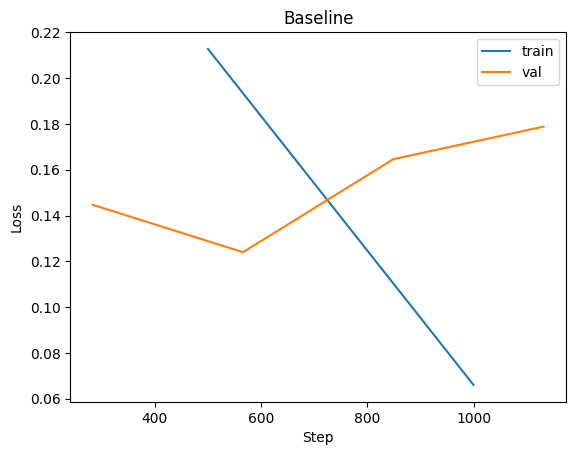

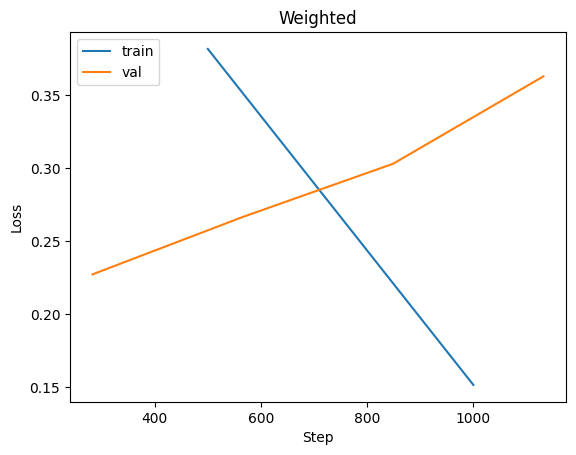

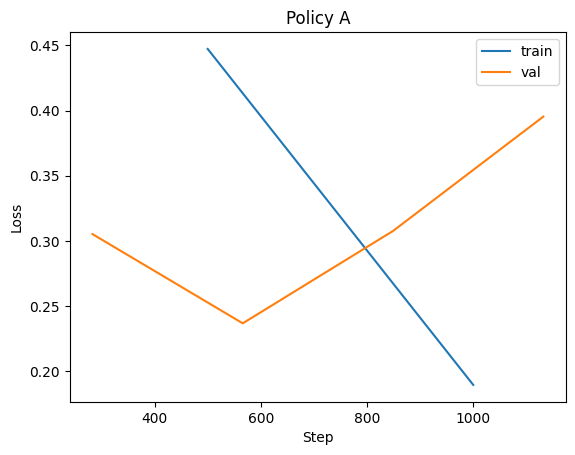

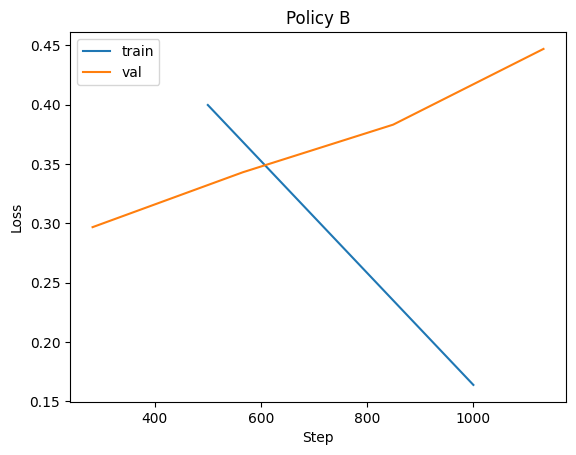

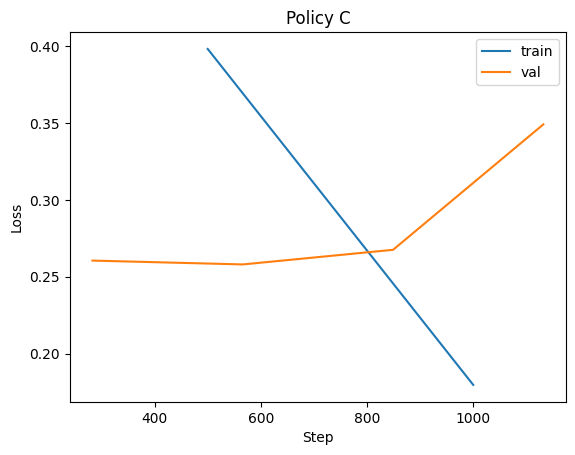

In [ ]:
plot_curved_from_results_folder("results/v1_baseline", "Baseline")
plot_curved_from_results_folder("results/v1b_weighted", "Weighted")
plot_curved_from_results_folder("results/v2_policy_A", "Policy A")
plot_curved_from_results_folder("results/v2_policy_B", "Policy B")
plot_curved_from_results_folder("results/v2_policy_C", "Policy C")